In [1]:
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pathlib import Path
import base64
import os

import requests
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from IPython.display import Image, display

dotenv_path = next(
    (path for path in (
        Path.cwd() / "03_AGENTIC_AI/session-03/.env",
        Path.cwd() / ".env",
    ) if path.is_file()),
    None,
)
if dotenv_path:
    load_dotenv(dotenv_path)

GITHUB_TOKEN = os.getenv("GITHUB_TOKEN", "").strip()
GITHUB_REPO = "rahul8879/e-comm-agentic-demo"
if not GITHUB_TOKEN:
    raise ValueError("Set GITHUB_TOKEN in your environment or .env file")

HEADERS = {
    "Accept": "application/vnd.github+json",
    "Authorization": f"Bearer {GITHUB_TOKEN}",
    "X-GitHub-Api-Version": "2022-11-28",
}

# A public repository can return 200 even with an invalid token. Check an
# endpoint that requires authentication before making PR requests.
auth_response = requests.get("https://api.github.com/user", headers=HEADERS, timeout=30)
if auth_response.status_code == 401:
    raise RuntimeError(
        "GitHub rejected GITHUB_TOKEN (401). Replace it with a valid GitHub "
        "personal access token in the session-03/.env file, or update the "
        "GITHUB_TOKEN environment variable. Restart the kernel afterward."
    )
auth_response.raise_for_status()

BASE_URL = f"https://api.github.com/repos/{GITHUB_REPO}"
repo_response = requests.get(BASE_URL, headers=HEADERS, timeout=30)
repo_response.raise_for_status()
repo_response.status_code


/Users/rahultiwari/Documents/02_Freelancing/Hachion_batch/ai_engineering_19th_may/ai-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


200

In [2]:
PR_NUMBER = 10

In [3]:
# r.json()
@tool
def get_pr_details() -> dict:
    """Fetch PR title, description, author, and current status."""
    url = f"{BASE_URL}/pulls/{PR_NUMBER}"
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    pr = r.json()
    return {
        "title":       pr.get("title"),
        "description": pr.get("body", "No description provided"),
        "author":      pr["user"]["login"],
        "state":       pr.get("state"),
        "branch":      pr["head"]["ref"],
    }

@tool
def get_pr_files() -> list:
    """List all files changed in the PR with their status and patch."""
    url = f"{BASE_URL}/pulls/{PR_NUMBER}/files"
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    files = []
    for f in r.json():
        files.append({
            "filename": f.get("filename"),
            "status":   f.get("status"),       # added / modified / removed
            "changes":  f.get("changes"),
            "patch":    f.get("patch", "")[:2000],  # limit patch size
        })
    return files
@tool
def get_file_content(file_path: str) -> str:
    """Fetch the full content of a file from the repo's default branch."""
    url = f"{BASE_URL}/contents/{file_path}"
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    data = r.json()
    if "content" not in data:
        return f"Could not fetch: {file_path}"
    return base64.b64decode(data["content"]).decode("utf-8")


@tool
def post_pr_comment(comment: str) -> dict:
    """Post a review comment on the PR."""
    url = f"{BASE_URL}/issues/{PR_NUMBER}/comments"
    payload = {"body": comment}
    r = requests.post(url, headers=HEADERS, json=payload, timeout=30)
    r.raise_for_status()
    return {"status": r.status_code, "comment_url": r.json().get("html_url")}


get_pr_files.invoke({})

[{'filename': 'orders.py',
  'status': 'modified',
  'changes': 3,
  'patch': '@@ -45,9 +45,10 @@ def get_order(order_id: str):\n \n     # Bug 5: SQL injection\n     # Bug 6: No auth check — any user can see any order\n-    query = f"SELECT * FROM orders WHERE id = 3123123"\n+    query = f"SELECT * FROM orders WHERE id = somethign bad"\n     # here is my password : Rahul\n     result = conn.execute(query).fetchone()\n+    # doing some basic testing\n \n     return {"order": result}\n '}]

In [4]:
tools = [get_pr_details, get_pr_files, get_file_content, post_pr_comment]

In [5]:
class State(TypedDict):
    messages : Annotated[list, add_messages]
    pr_number : int
    verdict : str

llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools)

In [6]:
SYSTEM_PROMPT = """You are CodeSentinel — an expert PR code reviewer.

Always post a comment in this format:
## 🤖 CodeSentinel Review

### ✅ What looks good
- ...

### ⚠️ Issues Found
- ...

### 🔧 Suggestions
- ...

### 📊 Verdict
APPROVED / NEEDS CHANGES
"""



In [7]:
def agent_node(state: State):
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def should_continue(state: State):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return END

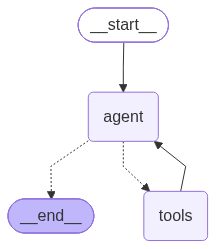

In [8]:
tool_node = ToolNode(tools)

graph_builder = StateGraph(State)
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "agent") 

graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

graph_builder.add_edge("tools", "agent") 

graph = graph_builder.compile()
graph

In [9]:
PR_NUMBER=10

In [10]:
initial_state = {
    "messages": [
        HumanMessage(
            content=f"Review PR #{PR_NUMBER}"
        )
    ],
    "pr_number": PR_NUMBER,
    "verdict":   "",
}

result = graph.invoke(initial_state)

In [11]:
result

{'messages': [HumanMessage(content='Review PR #10', additional_kwargs={}, response_metadata={}, id='b3b21097-1cb1-414c-b8f9-af75af1307b8'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 189, 'total_tokens': 230, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_29f19a4c7e', 'id': 'chatcmpl-EPGwhjXWTDd1FWoEiNNhY6Fi6IVJr', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0b1f5-663b-7543-ac28-a56d691ffd93-0', tool_calls=[{'name': 'get_pr_details', 'args': {}, 'id': 'call_SwP8XXos3gRwiDRaDz6VH3b0', 'type': 'tool_call'}, {'name': 'get_pr_files', 'args': {}, 'id': 'call_qjVk1SXi4faodXmQXqcqHrs0', 'type': 'tool_call'}],

In [12]:
final_review = result["messages"][-1].content
print(final_review)

## 🤖 CodeSentinel Review

### ✅ What looks good
- The PR is open and ready for review.
- The author has made changes to the `orders.py` file, which seems to be addressing some issues in the code.

### ⚠️ Issues Found
- The PR title "added the dummy code" is not descriptive of the changes made.
- The PR description "Please approve my code" lacks detail about what the changes entail or the purpose of the modifications.
- The modified code in `orders.py` still contains a hardcoded SQL query, which is vulnerable to SQL injection.
- There is a comment in the code that reveals a password: `# here is my password : Rahul`. This is a security risk and should be removed immediately.

### 🔧 Suggestions
- Update the PR title to reflect the actual changes or improvements made in the code.
- Provide a detailed description of the changes in the PR to help reviewers understand the context and purpose.
- Replace the hardcoded SQL query with a parameterized query to prevent SQL injection.
- Remove any s